In [8]:
import pandas as pd

# Load your data
df = pd.read_csv("AI_Dating_Study_Responses_Sheet1.csv")

# Quick check
print(df.head())


                    timestamp       participant_id  age             gender  \
0  2025-11-24T02:32:34.732332  PID_1763951480_1947   24  Prefer not to say   
1  2025-11-24T02:33:16.567018  PID_1763951480_1947   24  Prefer not to say   
2  2025-11-24T02:33:39.184555  PID_1763951480_1947   24  Prefer not to say   
3  2025-11-24T02:33:43.269222  PID_1763951480_1947   24  Prefer not to say   
4  2025-11-24T02:34:10.093633  PID_1763951480_1947   24  Prefer not to say   

  attraction       profile_id        condition  attractiveness  authenticity  \
0        Men               m2          control               2             2   
1        Men               m8     ai_disclosed               2             2   
2        Men               m3          control               2             2   
3        Men  attention_check  attention_check               3             3   
4        Men               m4     ai_disclosed               2             2   

   desirability  attention_check attention_correct

Number of full participants: 5

Full participants by attraction category:
  Men: 2
  Women: 3

Summary stats by condition (overall):
             attractiveness           authenticity           desirability  \
                       mean       sem         mean       sem         mean   
condition                                                                   
ai_disclosed           2.00  0.129099         1.80  0.152753         1.76   
control                2.08  0.162481         1.84  0.124900         1.84   

                        
                   sem  
condition               
ai_disclosed  0.104563  
control       0.110755  


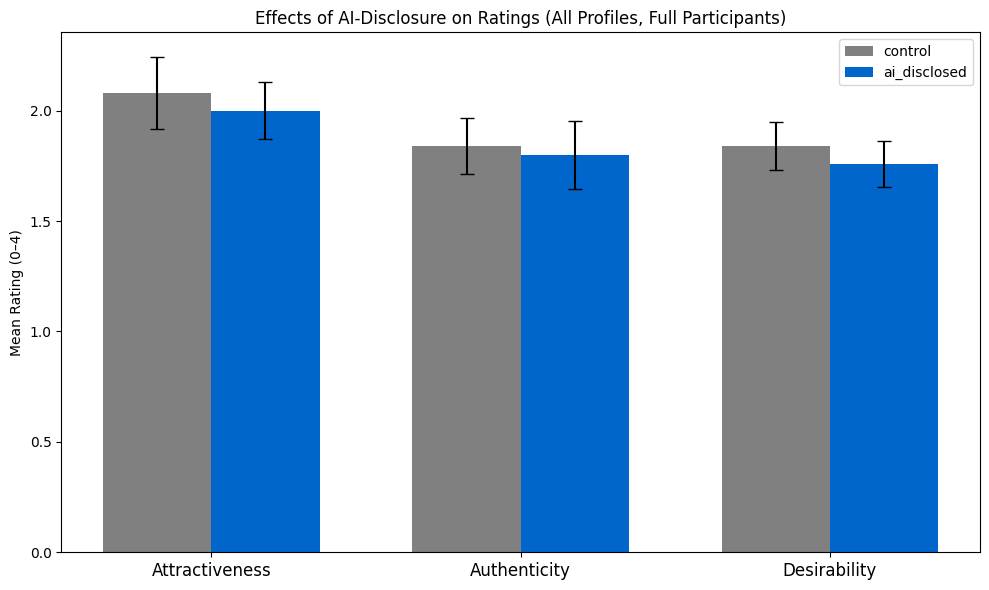

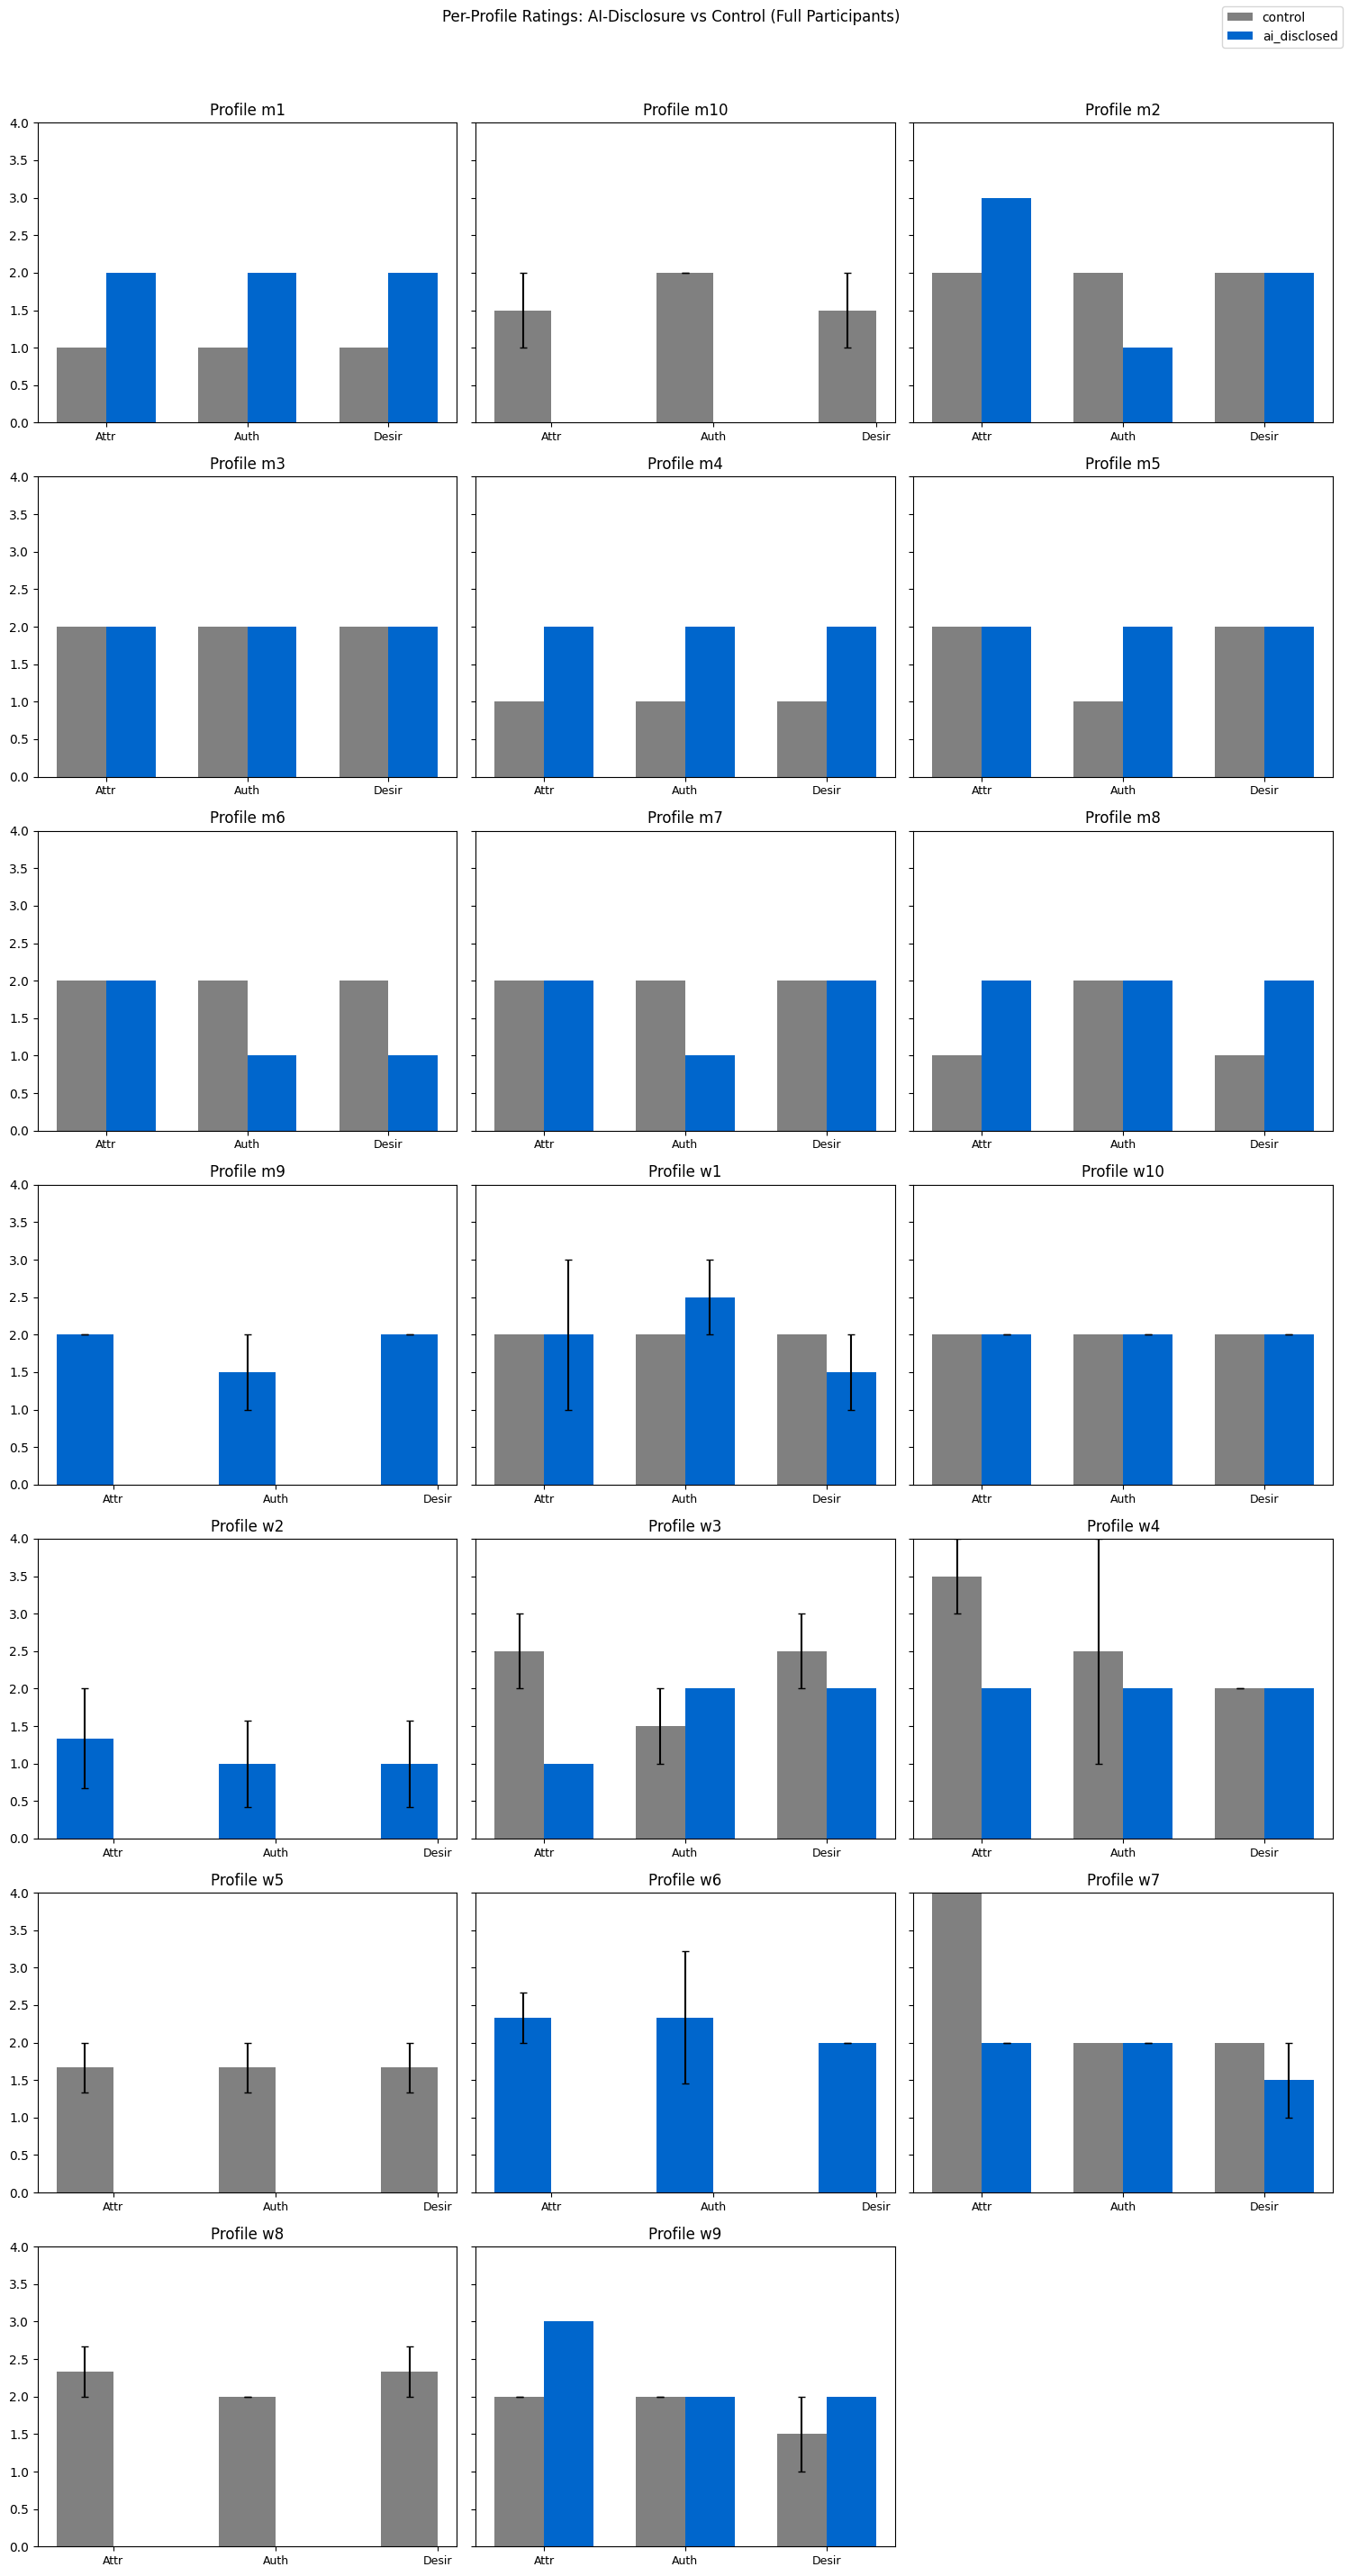



Summary stats by profile type and condition:
                          attractiveness           authenticity            \
                                    mean       sem         mean       sem   
profile_type condition                                                      
Female       ai_disclosed       1.933333  0.206252     1.933333  0.228174   
             control            2.400000  0.213809     1.933333  0.181703   
Male         ai_disclosed       2.100000  0.100000     1.600000  0.163299   
             control            1.600000  0.163299     1.700000  0.152753   

                          desirability            
                                  mean       sem  
profile_type condition                            
Female       ai_disclosed     1.666667  0.159364  
             control          2.000000  0.138013  
Male         ai_disclosed     1.900000  0.100000  
             control          1.600000  0.163299  


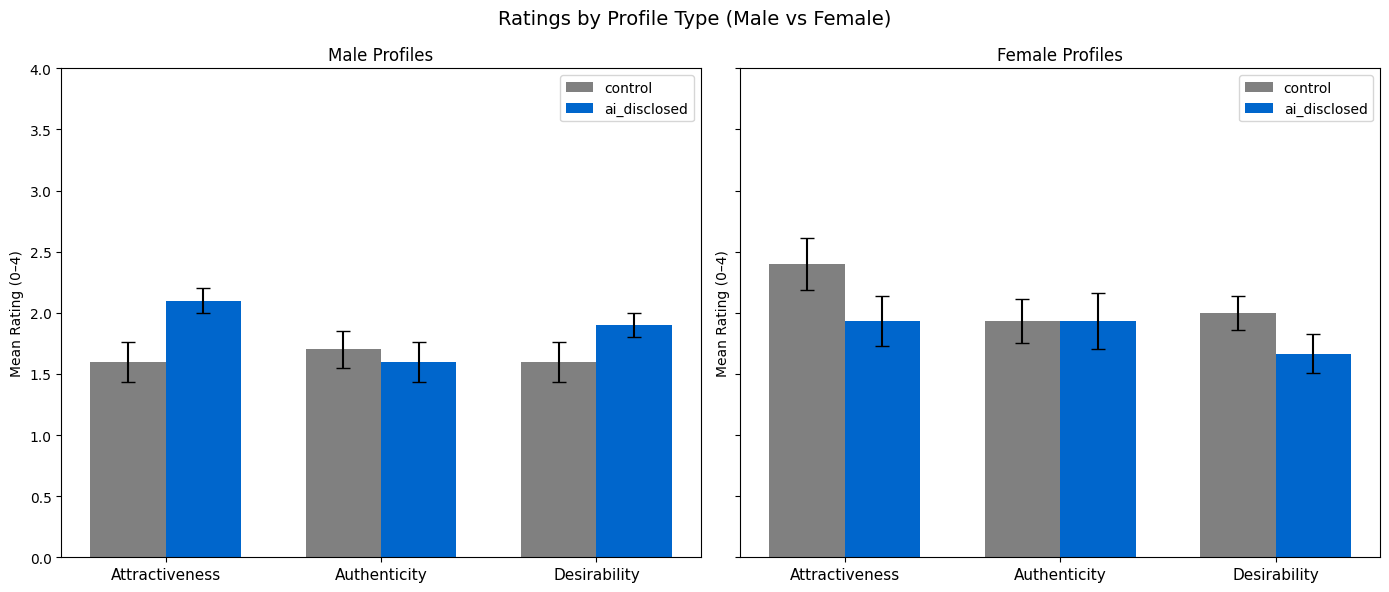

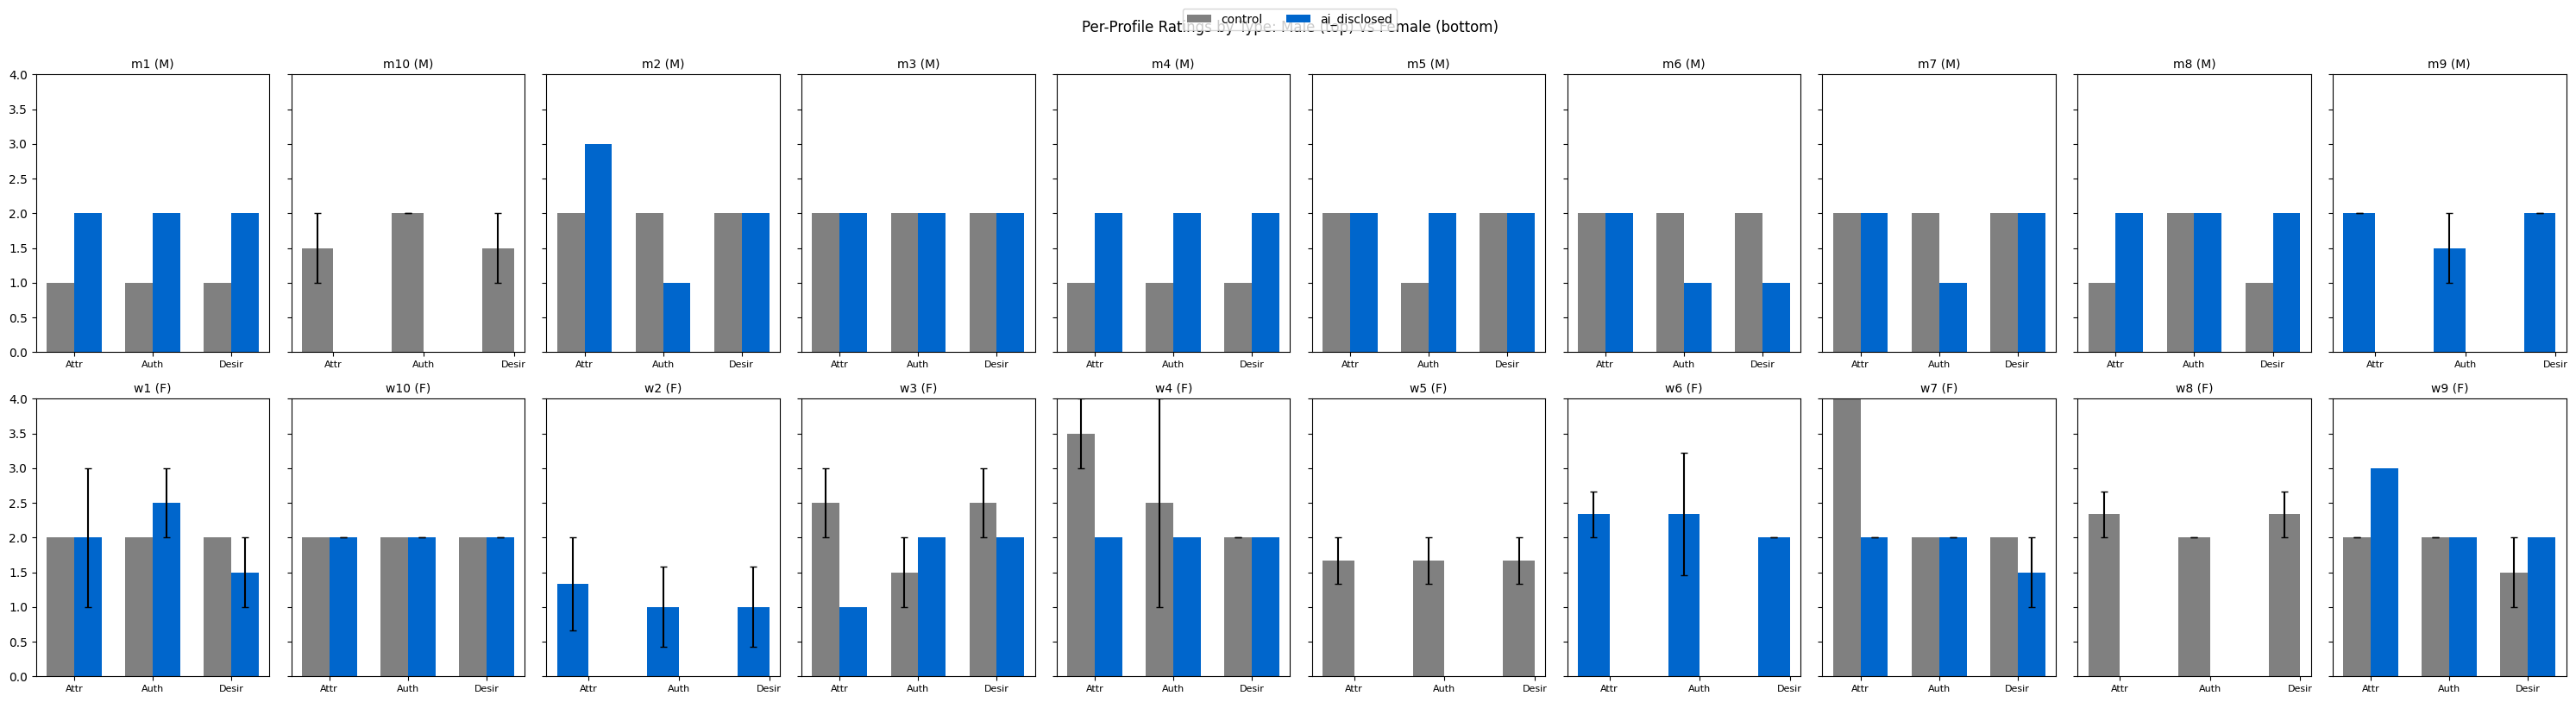

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------------------------
# 1. Keep only participants with exactly 11 responses
# -------------------------------------------------------------------
participant_counts = df.groupby("participant_id").size()
full_ids = participant_counts[participant_counts == 11].index

full_responses_df = df[df["participant_id"].isin(full_ids)].copy()

# -------------------------------------------------------------------
# 2. Participation summary: how many full participants,
#    and how many attracted to men / women / both
# -------------------------------------------------------------------
num_full_participants = full_responses_df["participant_id"].nunique()
print("Number of full participants:", num_full_participants)

attraction_counts = (
    full_responses_df
    .groupby("attraction")["participant_id"]
    .nunique()
)

print("\nFull participants by attraction category:")
for attr, count in attraction_counts.items():
    print(f"  {attr}: {count}")

# (Optionally, explicit vars if you need them later)
num_men = attraction_counts.get("Men", 0)
num_women = attraction_counts.get("Women", 0)
num_both = attraction_counts.get("Both", 0)

# -------------------------------------------------------------------
# 3. Filter: remove attention check rows
# -------------------------------------------------------------------
attn_df = full_responses_df[full_responses_df["profile_id"] != "attention_check"].copy()

# -------------------------------------------------------------------
# Define consistent colors for conditions
# -------------------------------------------------------------------
condition_colors = {
    "control": "#808080",      # grey
    "ai_disclosed": "#0066CC"  # blue
}
cond_order = ["control", "ai_disclosed"]

# -------------------------------------------------------------------
# 4. FIGURE 1: Effects of AI-Disclosure (overall, across profiles)
# -------------------------------------------------------------------
dvs = ["attractiveness", "authenticity", "desirability"]

# Compute means + SEM per condition
summary = attn_df.groupby("condition")[dvs].agg(["mean", "sem"])

print("\nSummary stats by condition (overall):")
print(summary)

conditions = summary.index.tolist()
x = np.arange(len(dvs))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Bar plot for each condition (in order: control, ai_disclosed)
present_conditions = [c for c in cond_order if c in summary.index]
for i, condition in enumerate(present_conditions):
    means = summary.loc[condition, (dvs, "mean")].values
    errors = summary.loc[condition, (dvs, "sem")].values

    ax.bar(
        x + i * width - width / 2,
        means,
        width,
        yerr=errors,
        capsize=5,
        label=condition,
        color=condition_colors.get(condition, "#000000")
    )

# Labels, formatting
ax.set_xticks(x)
ax.set_xticklabels(["Attractiveness", "Authenticity", "Desirability"], fontsize=12)
ax.set_ylabel("Mean Rating (0–4)")
ax.set_title("Effects of AI-Disclosure on Ratings (All Profiles, Full Participants)")
ax.legend()

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 5. FIGURE 2: Breakdown per profile_id
#    For each profile_id: 3 DVs x 2 conditions = 6 bars
#    One small subplot per profile
# -------------------------------------------------------------------

profile_ids = sorted(attn_df["profile_id"].unique())

n_profiles = len(profile_ids)
n_cols = 3  # layout choice; adjust if you want
n_rows = int(np.ceil(n_profiles / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharey=True)
axes = np.array(axes).reshape(-1)  # flatten in case of 1 row

width = 0.35
x = np.arange(len(dvs))

for i, pid in enumerate(profile_ids):
    ax = axes[i]
    prof_df = attn_df[attn_df["profile_id"] == pid]

    # Group by condition for this profile
    prof_summary = prof_df.groupby("condition")[dvs].agg(["mean", "sem"])

    # Determine which conditions are present (some profiles might be missing one)
    present_conditions = [c for c in cond_order if c in prof_summary.index]
    if not present_conditions:  # safety check
        ax.set_title(f"Profile {pid} (no data)")
        ax.axis("off")
        continue

    for j, condition in enumerate(present_conditions):
        means = prof_summary.loc[condition, (dvs, "mean")].values
        errors = prof_summary.loc[condition, (dvs, "sem")].values

        ax.bar(
            x + j * width - width / 2,
            means,
            width,
            yerr=errors,
            capsize=3,
            label=condition if i == 0 else None,  # only show legend labels once
            color=condition_colors.get(condition, "#000000")
        )

    ax.set_xticks(x)
    ax.set_xticklabels(["Attr", "Auth", "Desir"], fontsize=9)
    ax.set_title(f"Profile {pid}")
    ax.set_ylim(0, 4)  # ratings are on 0–4 scale

# Turn off empty subplots if n_profiles is not a multiple of n_cols
for k in range(n_profiles, len(axes)):
    axes[k].axis("off")

# One shared legend
handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="upper right")

fig.suptitle("Per-Profile Ratings: AI-Disclosure vs Control (Full Participants)", y=1.02)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 6. FIGURE 3: Breakdown by profile type (Male vs Female)
#    Profile IDs starting with 'm' = male, 'w' = female
# -------------------------------------------------------------------

# Create profile type column
attn_df["profile_type"] = attn_df["profile_id"].str[0].map({"m": "Male", "w": "Female"})

# Compute means + SEM per profile type and condition
type_summary = attn_df.groupby(["profile_type", "condition"])[dvs].agg(["mean", "sem"])

print("\n\nSummary stats by profile type and condition:")
print(type_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

profile_types = ["Male", "Female"]
width = 0.35
x = np.arange(len(dvs))

for type_idx, profile_type in enumerate(profile_types):
    ax = axes[type_idx]
    
    # Filter for this profile type
    if profile_type not in type_summary.index.get_level_values(0):
        ax.set_title(f"{profile_type} Profiles (no data)")
        continue
    
    # Get conditions present for this profile type
    present_conditions = [c for c in cond_order if c in type_summary.loc[profile_type].index]
    
    for cond_idx, condition in enumerate(present_conditions):
        means = type_summary.loc[(profile_type, condition), (dvs, "mean")].values
        errors = type_summary.loc[(profile_type, condition), (dvs, "sem")].values
        
        ax.bar(
            x + cond_idx * width - width / 2,
            means,
            width,
            yerr=errors,
            capsize=5,
            label=condition,
            color=condition_colors.get(condition, "#000000")
        )
    
    ax.set_xticks(x)
    ax.set_xticklabels(["Attractiveness", "Authenticity", "Desirability"], fontsize=11)
    ax.set_ylabel("Mean Rating (0–4)")
    ax.set_title(f"{profile_type} Profiles")
    ax.set_ylim(0, 4)
    ax.legend()

fig.suptitle("Ratings by Profile Type (Male vs Female)", fontsize=14)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 7. FIGURE 4: Per-profile breakdown, organized by profile type
# -------------------------------------------------------------------

# Separate profiles by type
male_profiles = sorted([p for p in profile_ids if p.startswith("m")])
female_profiles = sorted([p for p in profile_ids if p.startswith("w")])

fig, axes_list = plt.subplots(2, max(len(male_profiles), len(female_profiles)), 
                               figsize=(3 * max(len(male_profiles), len(female_profiles)), 8),
                               sharey=True)

if axes_list.ndim == 1:
    axes_list = axes_list.reshape(2, -1)

width = 0.35
x = np.arange(len(dvs))

# Male profiles (top row)
for col_idx, pid in enumerate(male_profiles):
    ax = axes_list[0, col_idx]
    prof_df = attn_df[attn_df["profile_id"] == pid]
    prof_summary = prof_df.groupby("condition")[dvs].agg(["mean", "sem"])
    
    present_conditions = [c for c in cond_order if c in prof_summary.index]
    if not present_conditions:
        ax.set_title(f"{pid} (no data)")
        ax.axis("off")
        continue
    
    for j, condition in enumerate(present_conditions):
        means = prof_summary.loc[condition, (dvs, "mean")].values
        errors = prof_summary.loc[condition, (dvs, "sem")].values
        
        ax.bar(
            x + j * width - width / 2,
            means,
            width,
            yerr=errors,
            capsize=3,
            label=condition if col_idx == 0 else None,
            color=condition_colors.get(condition, "#000000")
        )
    
    ax.set_xticks(x)
    ax.set_xticklabels(["Attr", "Auth", "Desir"], fontsize=8)
    ax.set_title(f"{pid} (M)", fontsize=10)
    ax.set_ylim(0, 4)

# Fill unused cells in top row
for col_idx in range(len(male_profiles), axes_list.shape[1]):
    axes_list[0, col_idx].axis("off")

# Female profiles (bottom row)
for col_idx, pid in enumerate(female_profiles):
    ax = axes_list[1, col_idx]
    prof_df = attn_df[attn_df["profile_id"] == pid]
    prof_summary = prof_df.groupby("condition")[dvs].agg(["mean", "sem"])
    
    present_conditions = [c for c in cond_order if c in prof_summary.index]
    if not present_conditions:
        ax.set_title(f"{pid} (no data)")
        ax.axis("off")
        continue
    
    for j, condition in enumerate(present_conditions):
        means = prof_summary.loc[condition, (dvs, "mean")].values
        errors = prof_summary.loc[condition, (dvs, "sem")].values
        
        ax.bar(
            x + j * width - width / 2,
            means,
            width,
            yerr=errors,
            capsize=3,
            label=condition if col_idx == 0 else None,
            color=condition_colors.get(condition, "#000000")
        )
    
    ax.set_xticks(x)
    ax.set_xticklabels(["Attr", "Auth", "Desir"], fontsize=8)
    ax.set_title(f"{pid} (F)", fontsize=10)
    ax.set_ylim(0, 4)

# Fill unused cells in bottom row
for col_idx in range(len(female_profiles), axes_list.shape[1]):
    axes_list[1, col_idx].axis("off")

# Shared legend
handles, labels = axes_list[0, 0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))

fig.suptitle("Per-Profile Ratings by Type: Male (top) vs Female (bottom)", y=0.995)
plt.tight_layout()
plt.show()
